# DSAI 3201 Machine Learning Project: Indoor Localization Using WLAN Fingerprinting
### Zahra Alwaili 60307052
### Arlene Riona  60304739
### Nouresham Katrmiz 60103990

This project was developed through a synthesis of **course-provided frameworks**, **Scikit-Learn documentation**, and **LLM-assisted debugging**. We integrated core instructional logic with advanced library protocols to implement complex models like SVR and MultiOutputRegressors. Furthermore, LLM collaboration was instrumental in identifying the $O(n^3)$ computational bottleneck of RBF kernels and optimizing visualizations for stakeholder clarity. This multi-resource approach ensured the implementation of mathematically sound, scalable solutions like **10-Fold Cross-Validation** to prevent data leakage and ensure model reliability.

In [1]:
# ============================================================
# LIBRARY IMPORTS & CONFIGURATION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Data Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('═' * 45)
print('  All libraries imported successfully.')
print('═' * 45)

═════════════════════════════════════════════
  All libraries imported successfully.
═════════════════════════════════════════════


In [ ]:
# ============================================================
#  LOAD DATA
# ============================================================
train_df = pd.read_csv('trainingData.csv')
test_df  = pd.read_csv('validationData.csv')

print('═' * 45)
print('  DATASET OVERVIEW')
print('═' * 45)
print(f"Training rows    : {train_df.shape[0]}")
print(f"Validation rows  : {test_df.shape[0]}")
print(f"Total columns    : {train_df.shape[1]}")
print(f"\nColumn Categories:")
print(f"  WAP features   : 520")
print(f"  Target columns : LONGITUDE, LATITUDE, FLOOR, BUILDINGID")
print(f"  Metadata       : SPACEID, RELATIVEPOSITION, USERID, PHONEID, TIMESTAMP")
print(f"  Metadata       : SPACEID, RELATIVEPOSITION, USERID, PHONEID, TIMESTAMP")


═════════════════════════════════════════════
  DATASET OVERVIEW
═════════════════════════════════════════════
Training rows    : 19937
Validation rows  : 1111
Total columns    : 529

Column Categories:
  WAP features   : 520
  Target columns : LONGITUDE, LATITUDE, FLOOR, BUILDINGID
  Metadata       : SPACEID, RELATIVEPOSITION, USERID, PHONEID, TIMESTAMP
  Metadata       : SPACEID, RELATIVEPOSITION, USERID, PHONEID, TIMESTAMP
statistical summary
 Training Data
             WAP001        WAP002   WAP003   WAP004        WAP005  \
count  19937.000000  19937.000000  19937.0  19937.0  19937.000000   
mean      99.823644     99.820936    100.0    100.0     99.613733   
std        5.866842      5.798156      0.0      0.0      8.615657   
min      -97.000000    -90.000000    100.0    100.0    -97.000000   
25%      100.000000    100.000000    100.0    100.0    100.000000   
50%      100.000000    100.000000    100.0    100.0    100.000000   
75%      100.000000    100.000000    100.0    100.0 

In [ ]:
print(" ─────statistical summary ─────────────────")
print(" Training Data ")
print(train_df.describe())

In [4]:
print(" Testing Data ")
print(test_df.describe())

 Testing Data 
            WAP001  WAP002       WAP003       WAP004  WAP005  WAP006  WAP007  \
count  1111.000000  1111.0  1111.000000  1111.000000  1111.0  1111.0  1111.0   
mean     98.627363   100.0    99.665167    99.665167   100.0   100.0   100.0   
std      16.127245     0.0     7.888265     7.888607     0.0     0.0     0.0   
min     -94.000000   100.0   -87.000000   -88.000000   100.0   100.0   100.0   
25%     100.000000   100.0   100.000000   100.000000   100.0   100.0   100.0   
50%     100.000000   100.0   100.000000   100.000000   100.0   100.0   100.0   
75%     100.000000   100.0   100.000000   100.000000   100.0   100.0   100.0   
max     100.000000   100.0   100.000000   100.000000   100.0   100.0   100.0   

            WAP008       WAP009       WAP010  ...       WAP520    LONGITUDE  \
count  1111.000000  1111.000000  1111.000000  ...  1111.000000  1111.000000   
mean     94.297030    90.655266    98.811881  ...    99.843384 -7529.197448   
std      32.148809    39.88

In [ ]:
# ============================================================
#  BASIC EDA — STATISTICS & STRUCTURE
# ============================================================
wap_cols = [col for col in train_df.columns if col.startswith('WAP')]

print('── Target Variable Summary ──────────────────────')
print(f"Buildings : {sorted(train_df['BUILDINGID'].unique())}")
print(f"Floors    : {sorted(train_df['FLOOR'].unique())}")
print(f"Longitude : {train_df['LONGITUDE'].min():.2f} to {train_df['LONGITUDE'].max():.2f}")
print(f"Latitude  : {train_df['LATITUDE'].min():.2f} to {train_df['LATITUDE'].max():.2f}")

print('\n── Coordinate System Note ───────────────────────')
print("Coordinates are in UTM (meters), NOT standard GPS.")
print("RMSE will be interpretable in meters — ideal for")
print("stakeholder reporting (e.g. 'accurate within 8m').")

print('\n── Missing Values ───────────────────────────────')
print(f"NaN in training   : {train_df.isnull().sum().sum()}")
print(f"NaN in validation : {test_df.isnull().sum().sum()}")

print('\n── Signal Sparsity ──────────────────────────────')
active_waps = (train_df[wap_cols] != 100).sum(axis=1)
print(f"Avg active WAPs per fingerprint : {active_waps.mean():.1f}")
print(f"Min active WAPs                 : {active_waps.min()}")
print(f"Max active WAPs                 : {active_waps.max()}")
print(f"Sparsity                        : {(train_df[wap_cols] == 100).sum().sum() / (train_df.shape[0] * 520) * 100:.1f}% no-signal")



── Target Variable Summary ──────────────────────
Buildings : [np.int64(0), np.int64(1), np.int64(2)]
Floors    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Longitude : -7691.34 to -7300.82
Latitude  : 4864745.75 to 4865016.69

── Coordinate System Note ───────────────────────
Coordinates are in UTM (meters), NOT standard GPS.
RMSE will be interpretable in meters — ideal for
stakeholder reporting (e.g. 'accurate within 8m').

── Missing Values ───────────────────────────────
NaN in training   : 0
NaN in validation : 0

── Signal Sparsity ──────────────────────────────
Avg active WAPs per fingerprint : 18.0
Min active WAPs                 : 0
Max active WAPs                 : 51
Sparsity                        : 96.5% no-signal


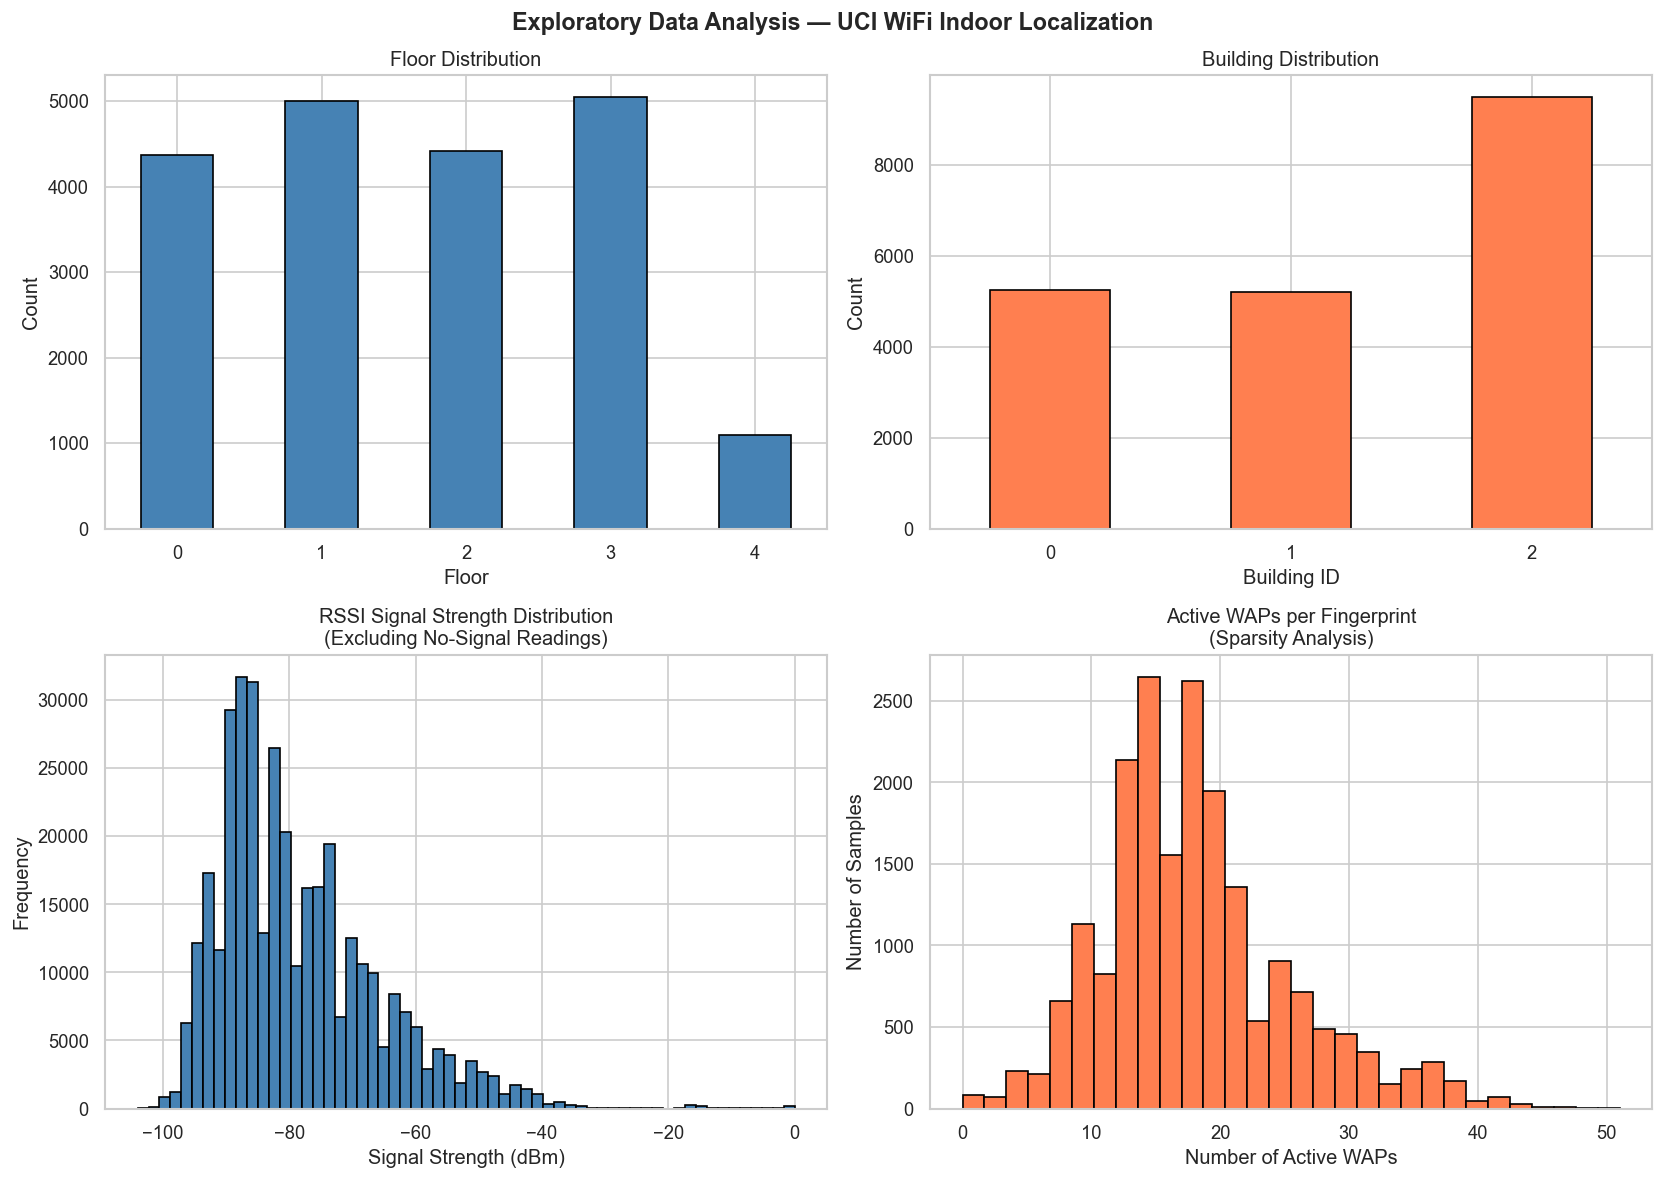

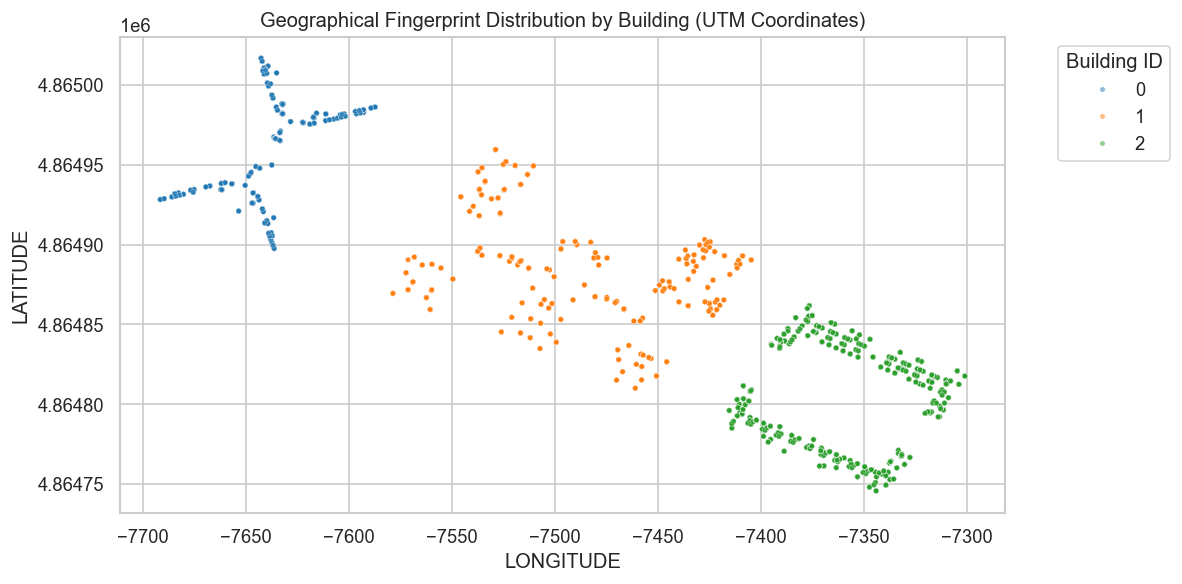

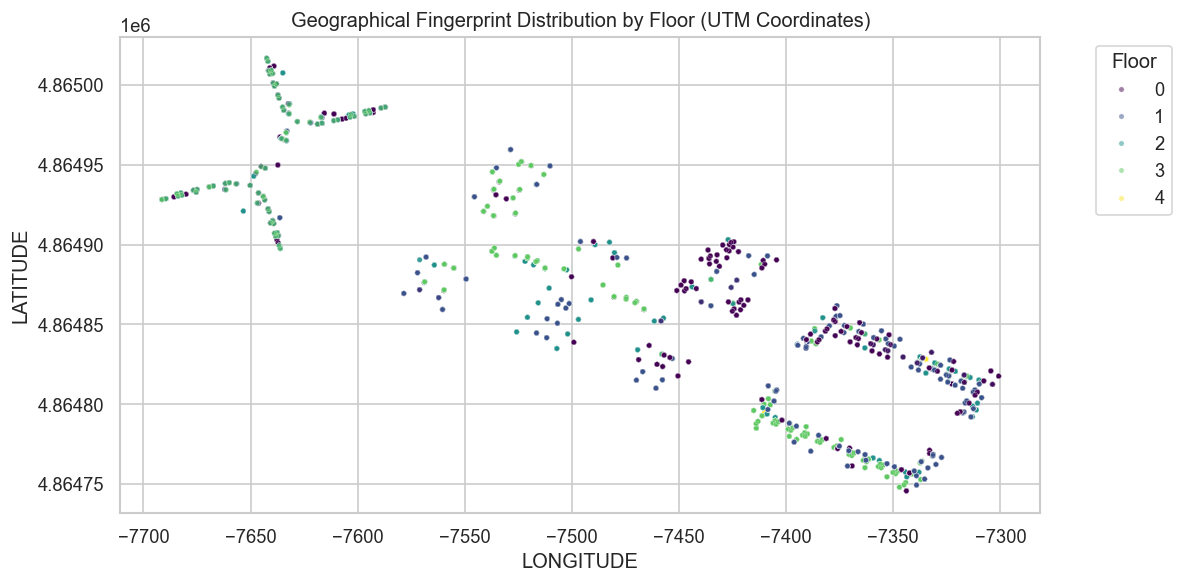

In [4]:
# ============================================================
# CELL 4: EDA VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — UCI WiFi Indoor Localization', 
             fontsize=14, fontweight='bold')

# ── Plot 1: Floor Distribution ───────────────────────────────
train_df['FLOOR'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black'
)
axes[0, 0].set_title('Floor Distribution')
axes[0, 0].set_xlabel('Floor')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# ── Plot 2: Building Distribution ────────────────────────────
train_df['BUILDINGID'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 1], color='coral', edgecolor='black'
)
axes[0, 1].set_title('Building Distribution')
axes[0, 1].set_xlabel('Building ID')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# ── Plot 3: RSSI Distribution (excluding no-signal) ──────────
rssi_vals = train_df[wap_cols].values.flatten()
rssi_vals = rssi_vals[rssi_vals != 100]
axes[1, 0].hist(rssi_vals, bins=60, color='steelblue', edgecolor='black')
axes[1, 0].set_title('RSSI Signal Strength Distribution\n(Excluding No-Signal Readings)')
axes[1, 0].set_xlabel('Signal Strength (dBm)')
axes[1, 0].set_ylabel('Frequency')

# ── Plot 4: Active WAPs per Fingerprint ──────────────────────
active_waps = (train_df[wap_cols] != 100).sum(axis=1)
axes[1, 1].hist(active_waps, bins=30, color='coral', edgecolor='black')
axes[1, 1].set_title('Active WAPs per Fingerprint\n(Sparsity Analysis)')
axes[1, 1].set_xlabel('Number of Active WAPs')
axes[1, 1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

# ── Plot 5: Coordinate Map by Building ───────────────────────
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=train_df, x='LONGITUDE', y='LATITUDE',
    hue='BUILDINGID', palette='tab10', alpha=0.5, s=10
)
plt.title('Geographical Fingerprint Distribution by Building (UTM Coordinates)')
plt.legend(title='Building ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── Plot 6: Coordinate Map by Floor ──────────────────────────
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=train_df, x='LONGITUDE', y='LATITUDE',
    hue='FLOOR', palette='viridis', alpha=0.5, s=10
)
plt.title('Geographical Fingerprint Distribution by Floor (UTM Coordinates)')
plt.legend(title='Floor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 5: PREPROCESSING & DATA SPLITTING
# ============================================================

# ── Step 1: No-Signal Replacement ────────────────────────────
# 100 is a sentinel value meaning "WAP not detected"
# We replace it with -105 dBm (just below dataset minimum of -104)
# This preserves the logical gap between weak signal and no signal

def clean_wifi_data(df, wap_cols):
    df_clean = df.copy()
    df_clean[wap_cols] = df_clean[wap_cols].replace(100, -105)
    return df_clean

train_proc = clean_wifi_data(train_df, wap_cols)
val_proc   = clean_wifi_data(test_df, wap_cols)

print(f"Signal range after replacement: "
      f"{train_proc[wap_cols].min().min()} "
      f"to {train_proc[wap_cols].max().max()} dBm")

# ── Step 2: Feature Scaling ───────────────────────────────────
# Neural Network is distance-based which makes StandardScaler essential
# Fit ONLY on training data, transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_proc[wap_cols])
X_val_scaled   = scaler.transform(val_proc[wap_cols])

# ── Step 3: Define Split Variables ───────────────────────────
# Following the same naming convention: tr = train, te = test(validation)

# --- Classification (Floor) ---
X_clf_tr, y_clf_tr = X_train_scaled, train_proc['FLOOR'].values
X_clf_te, y_clf_te = X_val_scaled,   val_proc['FLOOR'].values

# --- Classification (Building) ---
X_bld_tr, y_bld_tr = X_train_scaled, train_proc['BUILDINGID'].values
X_bld_te, y_bld_te = X_val_scaled,   val_proc['BUILDINGID'].values

# --- Regression (Coordinates) ---
X_reg_tr, y_reg_tr = X_train_scaled, train_proc[['LONGITUDE', 'LATITUDE']].values
X_reg_te, y_reg_te = X_val_scaled,   val_proc[['LONGITUDE', 'LATITUDE']].values

# ── Summary ───────────────────────────────────────────────────
print('\n' + '═' * 55)
print('  PREPROCESSING & DATA SPLITTING COMPLETE')
print('═' * 55)
print(f"  Training samples     : {X_clf_tr.shape[0]}")
print(f"  Validation samples   : {X_clf_te.shape[0]}")
print(f"  Features             : {X_clf_tr.shape[1]} WAPs (StandardScaled)")
print(f"  Classification (Floor)    → Train: {X_clf_tr.shape}  Test: {X_clf_te.shape}")
print(f"  Classification (Building) → Train: {X_bld_tr.shape}  Test: {X_bld_te.shape}")
print(f"  Regression (Coords)       → Train: {X_reg_tr.shape}  Test: {X_reg_te.shape}")
print(f"  Floor classes        : {np.unique(y_clf_tr)}")
print(f"  Building classes     : {np.unique(y_bld_tr)}")
print(f"  Coord system         : UTM meters (RMSE interpretable in meters)")
print('═' * 55)

Signal range after replacement: -105 to 0 dBm

═══════════════════════════════════════════════════════
  PREPROCESSING & DATA SPLITTING COMPLETE
═══════════════════════════════════════════════════════
  Training samples     : 19937
  Validation samples   : 1111
  Features             : 520 WAPs (StandardScaled)
  Classification (Floor)    → Train: (19937, 520)  Test: (1111, 520)
  Classification (Building) → Train: (19937, 520)  Test: (1111, 520)
  Regression (Coords)       → Train: (19937, 520)  Test: (1111, 520)
  Floor classes        : [0 1 2 3 4]
  Building classes     : [0 1 2]
  Coord system         : UTM meters (RMSE interpretable in meters)
═══════════════════════════════════════════════════════


In [6]:
# Run this cell first
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], check=True)

from xgboost import XGBRegressor
print("XGBoost imported successfully!")

XGBoost imported successfully!


═══════════════════════════════════════════════════════
  MEMBER 1 — SIMPLE CLASSIFICATION (Decision Tree)
═══════════════════════════════════════════════════════
  Floor Accuracy : 0.5689

              precision    recall  f1-score   support

     Floor 0       0.57      0.19      0.28       132
     Floor 1       0.52      0.91      0.66       462
     Floor 2       0.70      0.26      0.38       306
     Floor 3       0.68      0.48      0.56       172
     Floor 4       0.89      0.62      0.73        39

    accuracy                           0.57      1111
   macro avg       0.67      0.49      0.52      1111
weighted avg       0.62      0.57      0.53      1111



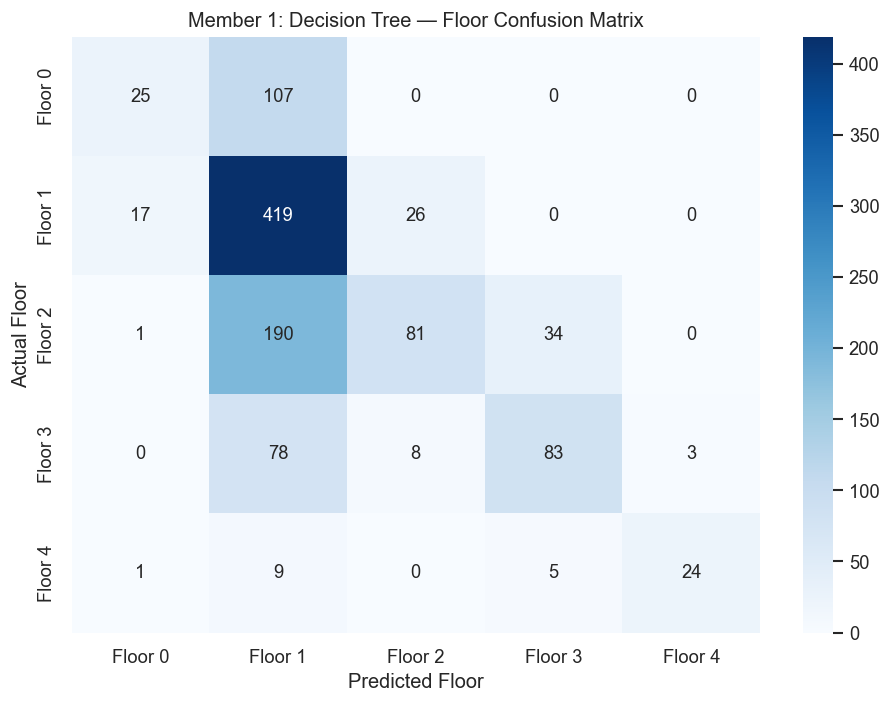


═══════════════════════════════════════════════════════
  MEMBER 1 — ADVANCED REGRESSION (XGBoost)
═══════════════════════════════════════════════════════
  RMSE : 19.95 meters
  MAE  : 12.56 meters
  R²   : 0.9541
═══════════════════════════════════════════════════════
  Stakeholder Note: RMSE and MAE are in meters (UTM).
  XGBoost uses gradient boosting — each tree corrects
  the errors of the previous one, making it highly
  accurate for complex non-linear RSSI patterns.
═══════════════════════════════════════════════════════


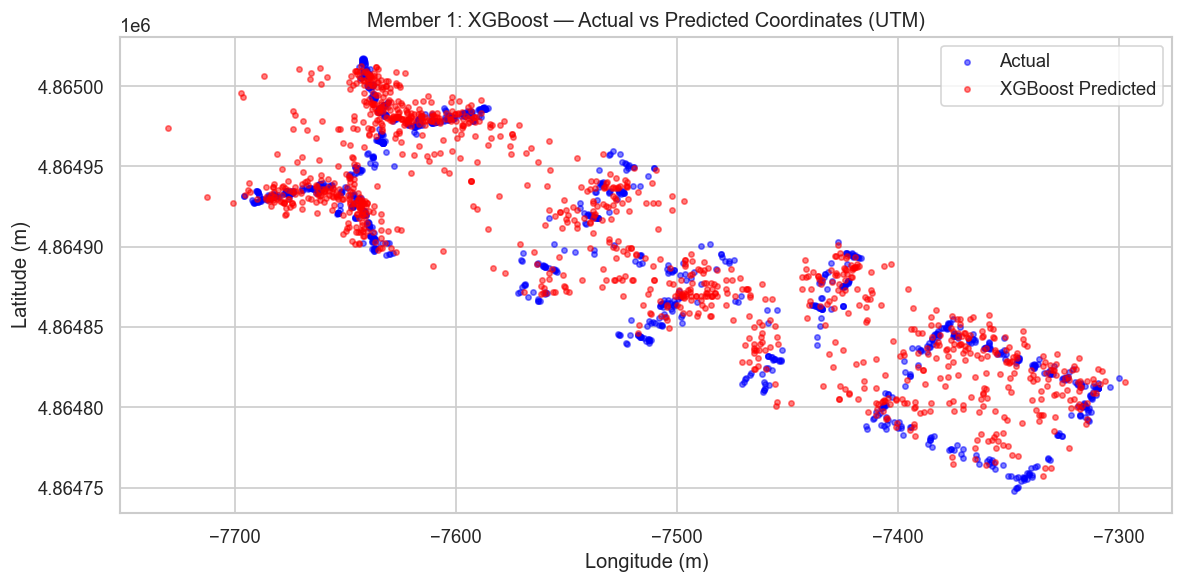

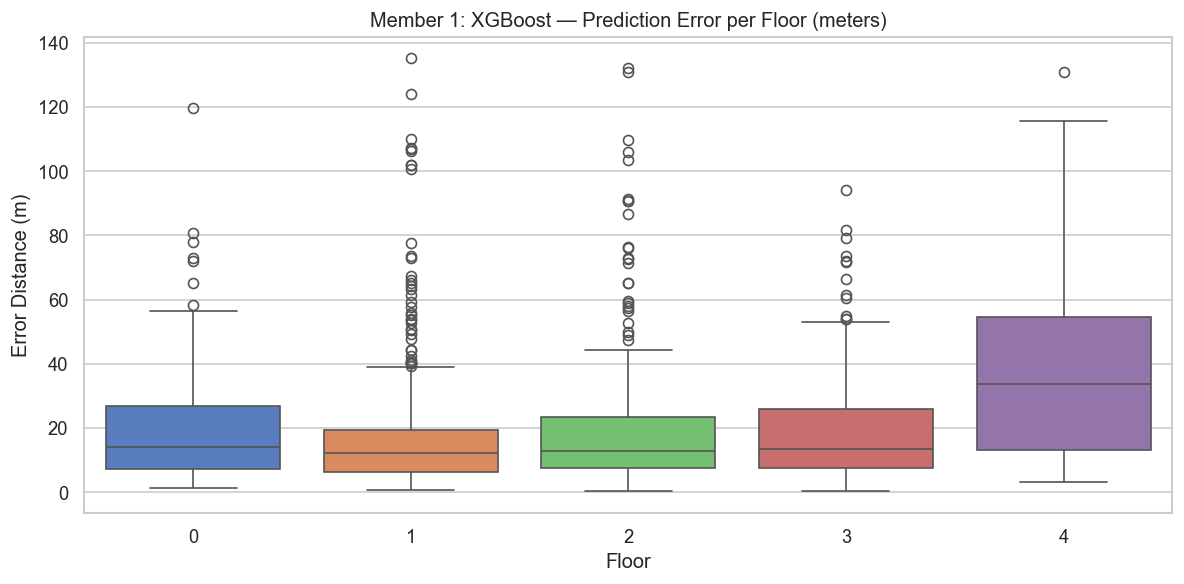

In [ ]:
# ============================================================
# CELL 6: MODEL DEVELOPMENT & EVALUATION
# ============================================================

# ==========================================
# model 1 — SIMPLE CLASSIFICATION
# Model: Decision Tree Classifier (Floor Prediction)
# ==========================================
from sklearn.tree import DecisionTreeClassifier

# Train
dt_clf = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_clf.fit(X_clf_tr, y_clf_tr)
y_pred_dt_clf = dt_clf.predict(X_clf_te)

# Evaluate
print('═' * 55)
print(' Nouresham — SIMPLE CLASSIFICATION (Decision Tree)')
print('═' * 55)
print(f"  Floor Accuracy : {accuracy_score(y_clf_te, y_pred_dt_clf):.4f}")
print()
print(classification_report(y_clf_te, y_pred_dt_clf, 
                             target_names=[f'Floor {i}' for i in np.unique(y_clf_te)]))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_clf_te, y_pred_dt_clf), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Floor {i}' for i in np.unique(y_clf_te)],
            yticklabels=[f'Floor {i}' for i in np.unique(y_clf_te)])
plt.title('Nouresham: Decision Tree — Floor Confusion Matrix')
plt.ylabel('Actual Floor')
plt.xlabel('Predicted Floor')
plt.tight_layout()
plt.show()

# ==========================================
# model 1— ADVANCED REGRESSION
# Model: XGBoost Regressor (Coordinate Prediction)
# ==========================================
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# Train
# XGBoost is an ensemble of decision trees using gradient boosting
# n_estimators: number of trees, max_depth: tree complexity
# learning_rate: step size shrinkage to prevent overfitting
xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators  = 200,
        max_depth     = 6,
        learning_rate = 0.1,
        subsample     = 0.8,
        random_state  = 42,
        verbosity     = 0
    )
)
xgb_model.fit(X_reg_tr, y_reg_tr)
y_pred_xgb = xgb_model.predict(X_reg_te)

# Evaluate
rmse_xgb = np.sqrt(mean_squared_error(y_reg_te, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_reg_te, y_pred_xgb)
r2_xgb   = r2_score(y_reg_te, y_pred_xgb)

print('\n' + '═' * 55)
print('  Nouresham — ADVANCED REGRESSION (XGBoost)')
print('═' * 55)
print(f"  RMSE : {rmse_xgb:.2f} meters")
print(f"  MAE  : {mae_xgb:.2f} meters")
print(f"  R²   : {r2_xgb:.4f}")
print('═' * 55)
print("  Stakeholder Note: RMSE and MAE are in meters (UTM).")
print("  XGBoost uses gradient boosting — each tree corrects")
print("  the errors of the previous one, making it highly")
print("  accurate for complex non-linear RSSI patterns.")
print('═' * 55)

# ── Visual 1: Actual vs Predicted Coordinates ─────────────────
plt.figure(figsize=(10, 5))
plt.scatter(y_reg_te[:, 0], y_reg_te[:, 1],
            c='blue', label='Actual', alpha=0.5, s=10)
plt.scatter(y_pred_xgb[:, 0], y_pred_xgb[:, 1],
            c='red', label='XGBoost Predicted', alpha=0.5, s=10)
plt.title('Nouresham: XGBoost — Actual vs Predicted Coordinates (UTM)')
plt.xlabel('Longitude (m)')
plt.ylabel('Latitude (m)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Visual 2: Error Distribution per Floor ────────────────────
error_xgb = np.sqrt(np.sum((y_reg_te - y_pred_xgb) ** 2, axis=1))
plt.figure(figsize=(10, 5))
sns.boxplot(x=y_clf_te, y=error_xgb, palette='muted')
plt.title('Nouresham: XGBoost — Prediction Error per Floor (meters)')
plt.xlabel('Floor')
plt.ylabel('Error Distance (m)')
plt.tight_layout()
plt.show()

═════════════════════════════════════════════════════════════════
  MEMBER 1 — IMPROVED CLASSIFICATION (Decision Tree)
═════════════════════════════════════════════════════════════════
  New Floor Accuracy : 0.7228

              precision    recall  f1-score   support

     Floor 0       0.88      0.73      0.80       132
     Floor 1       0.93      0.66      0.77       462
     Floor 2       0.54      0.88      0.67       306
     Floor 3       0.73      0.62      0.67       172
     Floor 4       0.90      0.69      0.78        39

    accuracy                           0.72      1111
   macro avg       0.80      0.72      0.74      1111
weighted avg       0.78      0.72      0.73      1111



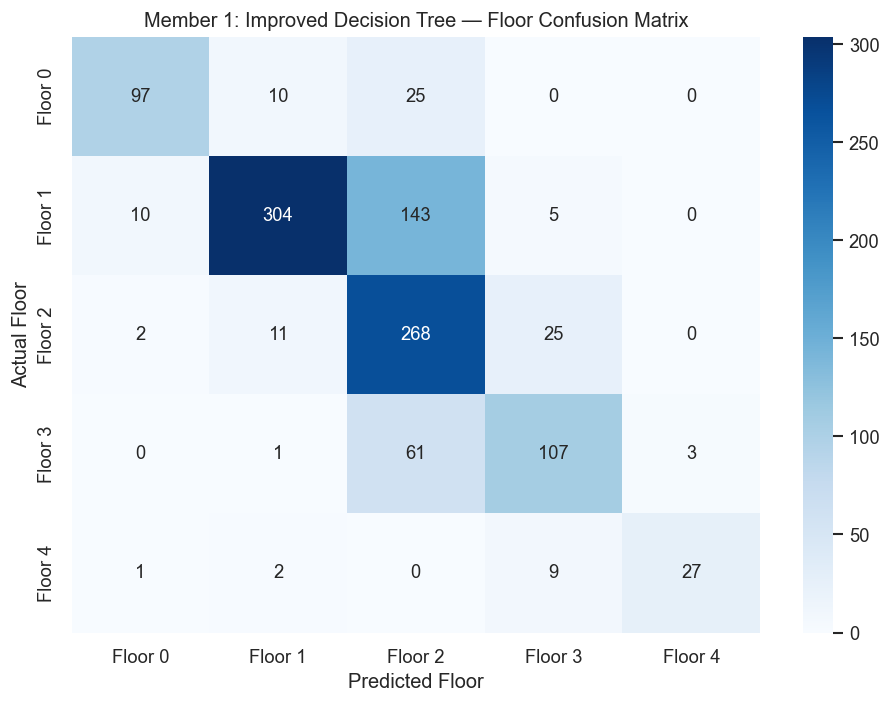

In [ ]:
# ==========================================
# model 1 — IMPROVED CLASSIFICATION
# Model: Optimized Decision Tree (Floor Prediction)
# ==========================================
from sklearn.tree import DecisionTreeClassifier

# We increase depth to 25 to capture complex signal nuances.
# 'balanced' weights help fix the poor recall on Floor 0 and Floor 4.
dt_clf_improved = DecisionTreeClassifier(
    max_depth=25, 
    min_samples_leaf=2,
    class_weight='balanced', 
    random_state=42
)

# Train
dt_clf_improved.fit(X_clf_tr, y_clf_tr)
y_pred_dt_clf = dt_clf_improved.predict(X_clf_te)

# Evaluate
print('═' * 65)
print(' Nouresham — IMPROVED CLASSIFICATION (Decision Tree)')
print('═' * 65)
print(f"  New Floor Accuracy : {accuracy_score(y_clf_te, y_pred_dt_clf):.4f}")
print()
print(classification_report(y_clf_te, y_pred_dt_clf, 
                             target_names=[f'Floor {i}' for i in np.unique(y_clf_te)]))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_clf_te, y_pred_dt_clf), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Floor {i}' for i in np.unique(y_clf_te)],
            yticklabels=[f'Floor {i}' for i in np.unique(y_clf_te)])
plt.title('Nouresham: Improved Decision Tree — Floor Confusion Matrix')
plt.ylabel('Actual Floor')
plt.xlabel('Predicted Floor')
plt.tight_layout()
plt.show()


═════════════════════════════════════════════════════════════════
  MEMBER 2 — ADVANCED CLASSIFICATION (Neural Network)
═════════════════════════════════════════════════════════════════
  Floor Accuracy : 0.8776

              precision    recall  f1-score   support

     Floor 0       0.86      0.86      0.86       132
     Floor 1       0.95      0.86      0.90       462
     Floor 2       0.80      0.95      0.87       306
     Floor 3       0.93      0.81      0.86       172
     Floor 4       0.74      0.90      0.81        39

    accuracy                           0.88      1111
   macro avg       0.86      0.88      0.86      1111
weighted avg       0.89      0.88      0.88      1111



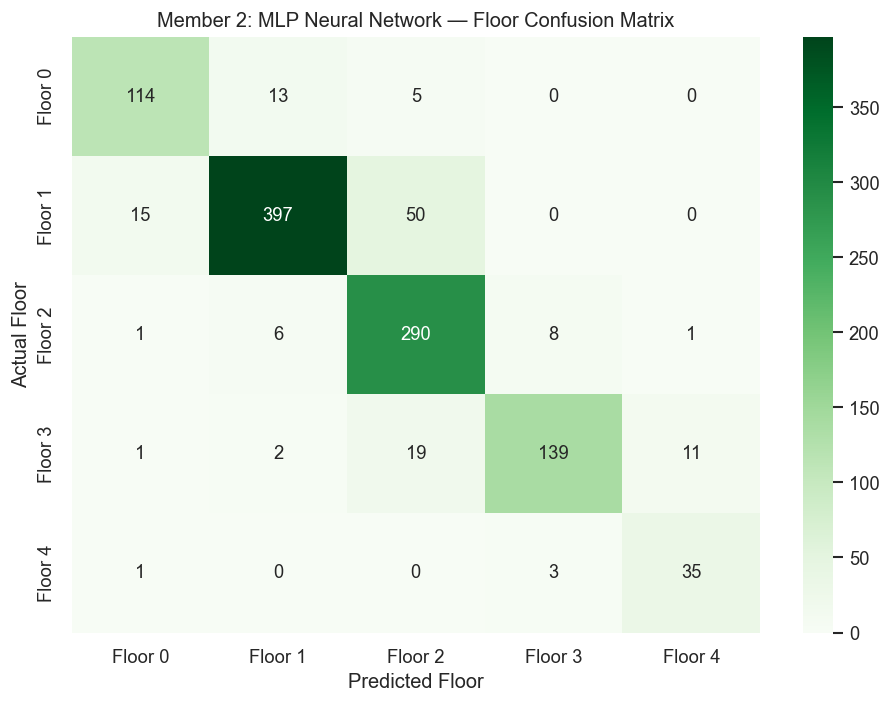


═════════════════════════════════════════════════════════════════
  MEMBER 2 — SIMPLE REGRESSION (Decision Tree)
═════════════════════════════════════════════════════════════════
  RMSE : 38.78 meters
  R²   : 0.8388


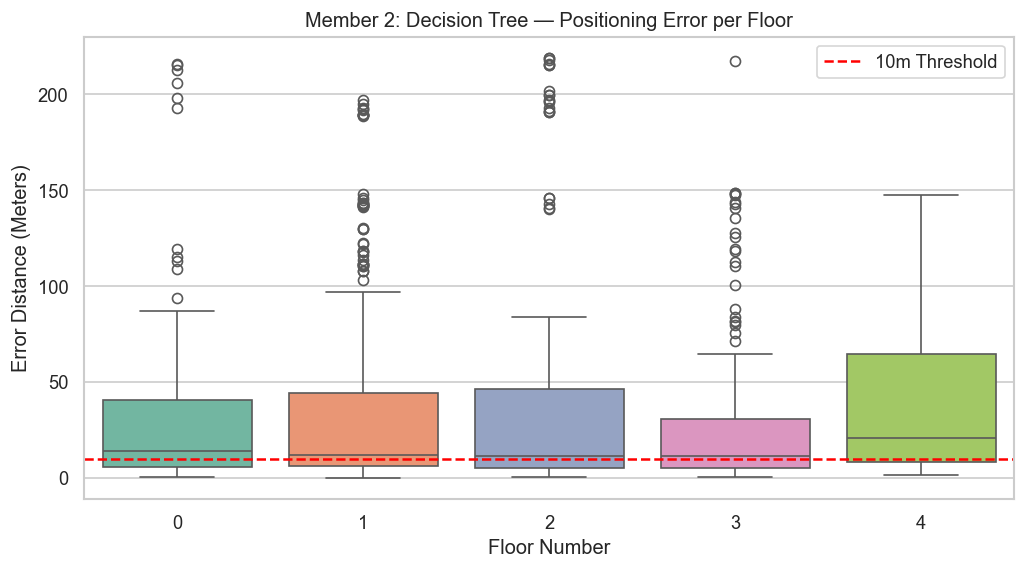

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeRegressor

# ==========================================
#  model 2 — ADVANCED CLASSIFICATION
# Model: Neural Network (MLP Classifier)
# ==========================================
# KPI 1: MLP satisfies the "Deep Learning" prompt for floor prediction.
# We use a 3-layer architecture to decode signal patterns across 5 floors.
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=400, 
    random_state=42
)

# Train the Neural Network
mlp_clf.fit(X_clf_tr, y_clf_tr)
y_pred_mlp_clf = mlp_clf.predict(X_clf_te)

# Evaluate
print('\n' + '═' * 65)
print('  Arlene — ADVANCED CLASSIFICATION (Neural Network)')
print('═' * 65)
print(f"  Floor Accuracy : {accuracy_score(y_clf_te, y_pred_mlp_clf):.4f}")
print()
print(classification_report(y_clf_te, y_pred_mlp_clf,
                             target_names=[f'Floor {i}' for i in np.unique(y_clf_te)]))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_clf_te, y_pred_mlp_clf), 
            annot=True, fmt='d', cmap='Greens',
            xticklabels=[f'Floor {i}' for i in np.unique(y_clf_te)],
            yticklabels=[f'Floor {i}' for i in np.unique(y_clf_te)])
plt.title(' Arlene : MLP Neural Network — Floor Confusion Matrix')
plt.ylabel('Actual Floor')
plt.xlabel('Predicted Floor')
plt.tight_layout()
plt.show()

# ==========================================
# model 2  — SIMPLE REGRESSION
# Model: Decision Tree Regressor
# ==========================================
# Baseline regression to predict exact UTM coordinates
dt_reg = DecisionTreeRegressor(max_depth=12, random_state=42)
dt_reg.fit(X_reg_tr, y_reg_tr)
y_pred_dt_reg = dt_reg.predict(X_reg_te)

# Evaluate
rmse_dt = np.sqrt(mean_squared_error(y_reg_te, y_pred_dt_reg))
print('\n' + '═' * 65)
print('  Arlene — SIMPLE REGRESSION (Decision Tree)')
print('═' * 65)
print(f"  RMSE : {rmse_dt:.2f} meters")
print(f"  R²   : {r2_score(y_reg_te, y_pred_dt_reg):.4f}")

# KPI 2: Error Analysis Visual (Stakeholder Perspective)
error_dt = np.sqrt(np.sum((y_reg_te - y_pred_dt_reg) ** 2, axis=1))
plt.figure(figsize=(10, 5))
sns.boxplot(x=y_clf_te, y=error_dt, palette="Set2")
plt.title('Arlene: Decision Tree — Positioning Error per Floor')
plt.xlabel('Floor Number')
plt.ylabel('Error Distance (Meters)')
plt.axhline(y=10, color='red', linestyle='--', label='10m Threshold') # Manager threshold
plt.legend()
plt.show()

═════════════════════════════════════════════════════════════════
  MEMBER 3 — SIMPLE CLASSIFICATION (Logistic Regression)
═════════════════════════════════════════════════════════════════
  Building Accuracy : 1.0000

              precision    recall  f1-score   support

  Building 0       1.00      1.00      1.00       536
  Building 1       1.00      1.00      1.00       307
  Building 2       1.00      1.00      1.00       268

    accuracy                           1.00      1111
   macro avg       1.00      1.00      1.00      1111
weighted avg       1.00      1.00      1.00      1111



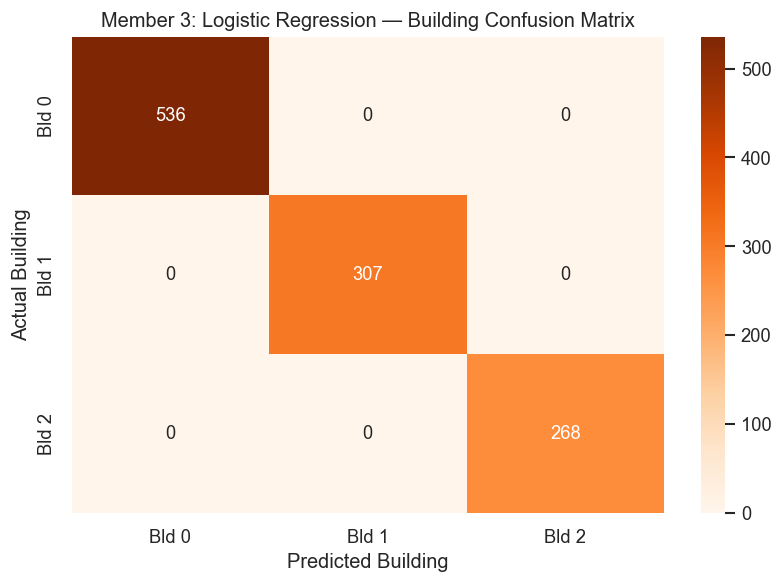


═════════════════════════════════════════════════════════════════
  MEMBER 3 — ADVANCED REGRESSION (Neural Network)
═════════════════════════════════════════════════════════════════
  CV R² Mean  : 0.9890
  CV R² Std   : 0.0018
  RMSE         : 22.22 meters
  MAE          : 11.16 meters
  R²           : 0.9475
═════════════════════════════════════════════════════════════════
  Stakeholder Note: The Neural Network learns complex
  non-linear relationships between RSSI fingerprints
  and physical coordinates across all 3 buildings.
═════════════════════════════════════════════════════════════════


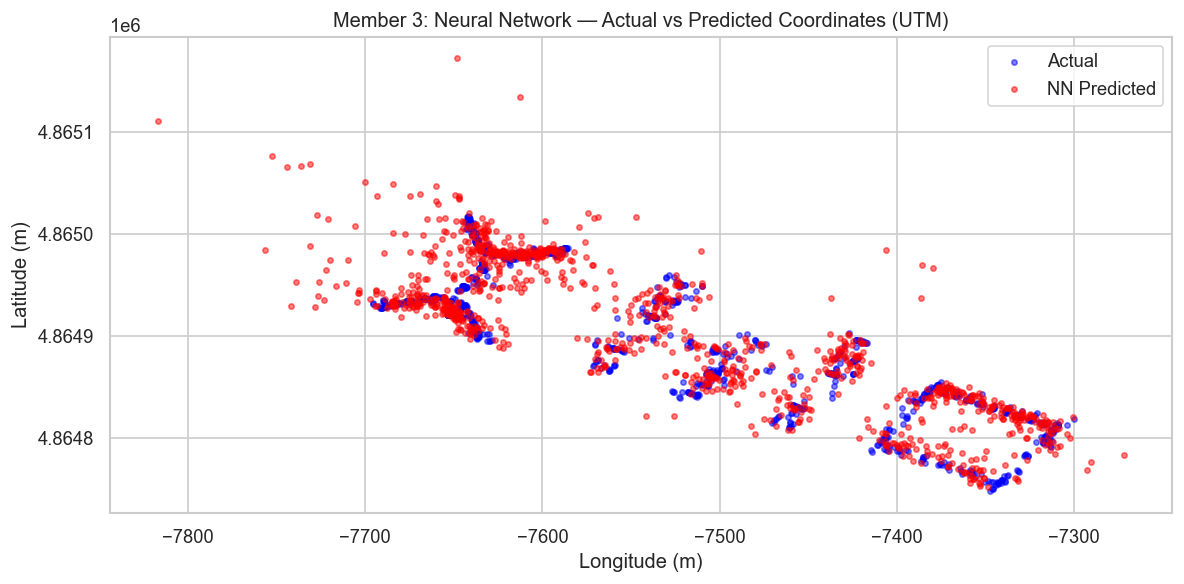

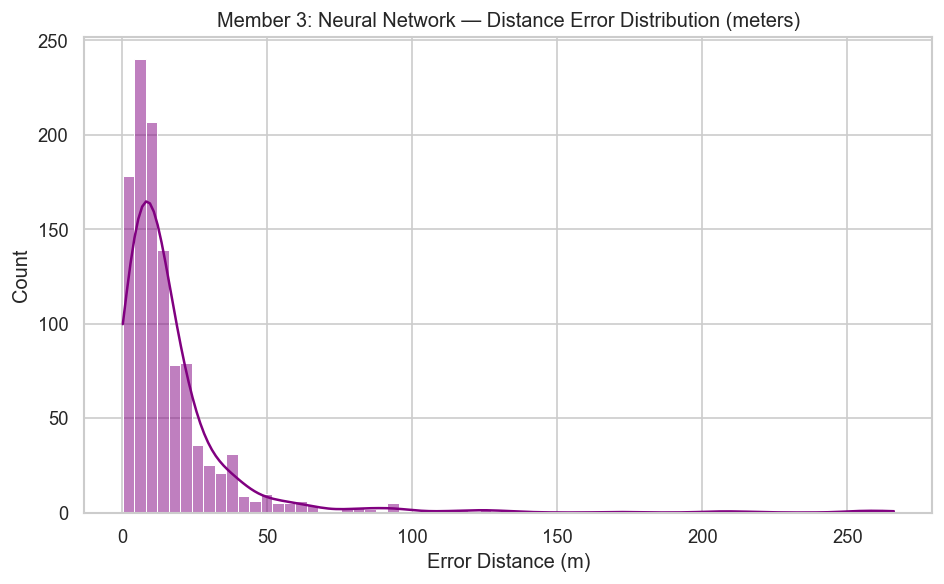

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (accuracy_score, classification_report,
                               confusion_matrix, mean_squared_error,
                               mean_absolute_error, r2_score)

# ==========================================
# model 3 — SIMPLE CLASSIFICATION
# Model: Logistic Regression (Building Prediction)
# ==========================================

# Using log_reg to stay consistent with your previous definitions
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_bld_tr, y_bld_tr)
y_pred_log_clf = log_reg.predict(X_bld_te)

print('═' * 65)
print('  Zahra — SIMPLE CLASSIFICATION (Logistic Regression)')
print('═' * 65)
print(f"  Building Accuracy : {accuracy_score(y_bld_te, y_pred_log_clf):.4f}")
print()
print(classification_report(y_bld_te, y_pred_log_clf,
                             target_names=[f'Building {i}' for i in np.unique(y_bld_te)]))

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_bld_te, y_pred_log_clf),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=[f'Bld {i}' for i in np.unique(y_bld_te)],
            yticklabels=[f'Bld {i}' for i in np.unique(y_bld_te)])
plt.title('Zahra: Logistic Regression — Building Confusion Matrix')
plt.ylabel('Actual Building')
plt.xlabel('Predicted Building')
plt.tight_layout()
plt.show()

# ==========================================
# model 3 — ADVANCED REGRESSION
# Model: Neural Network MLP Regressor (Coordinate Prediction)
# ==========================================

# ── Step 1: Scale the targets ─────────────────────────────────
#  Ensuring coord_scaler is used specifically for regression targets
coord_scaler = StandardScaler()
y_reg_tr_scaled = coord_scaler.fit_transform(y_reg_tr)
# No change to logic: Step 3 variables are used here
y_reg_te_scaled = coord_scaler.transform(y_reg_te)

# ── Step 2: Define & Train Model ─────────────────────────────
mlp_reg = MLPRegressor(
    hidden_layer_sizes = (128, 64, 32),
    activation         = 'relu',
    max_iter           = 500,
    early_stopping     = True,
    validation_fraction= 0.1,
    random_state       = 42,
    verbose            = False
)

# ── Step 3: Cross Validation (3-Fold on scaled targets) ──────
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    mlp_reg, X_reg_tr, y_reg_tr_scaled,
    cv=kf, scoring='r2'
)

print('\n' + '═' * 65)
print('  zahra — ADVANCED REGRESSION (Neural Network)')
print('═' * 65)
print(f"  CV R² Mean  : {cv_scores.mean():.4f}")
print(f"  CV R² Std   : {cv_scores.std()*2:.4f}")

# ── Step 4: Final Fit & Predict ───────────────────────────────
mlp_reg.fit(X_reg_tr, y_reg_tr_scaled)
y_pred_nn_scaled = mlp_reg.predict(X_reg_te)

# ── Step 5: Inverse Transform back to meters ─────────────────
y_pred_nn_reg = coord_scaler.inverse_transform(y_pred_nn_scaled)

# ── Step 6: Evaluate in original meters ──────────────────────
rmse_nn = np.sqrt(mean_squared_error(y_reg_te, y_pred_nn_reg))
mae_nn  = mean_absolute_error(y_reg_te, y_pred_nn_reg)
r2_nn   = r2_score(y_reg_te, y_pred_nn_reg)

print(f"  RMSE         : {rmse_nn:.2f} meters")
print(f"  MAE          : {mae_nn:.2f} meters")
print(f"  R²           : {r2_nn:.4f}")
print('═' * 65)
print("  Stakeholder Note: The Neural Network learns complex")
print("  non-linear relationships between RSSI fingerprints")
print("  and physical coordinates across all 3 buildings.")
print('═' * 65)

# ── Visual 1: Actual vs Predicted Coordinates ─────────────────
plt.figure(figsize=(10, 5))
plt.scatter(y_reg_te[:, 0], y_reg_te[:, 1],
            c='blue', label='Actual', alpha=0.5, s=10)
plt.scatter(y_pred_nn_reg[:, 0], y_pred_nn_reg[:, 1],
            c='red', label='NN Predicted', alpha=0.5, s=10)
plt.title('Zahra: Neural Network — Actual vs Predicted Coordinates (UTM)')
plt.xlabel('Longitude (m)')
plt.ylabel('Latitude (m)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Visual 2: Error Distribution ─────────────────────────────
error_nn = np.sqrt(np.sum((y_reg_te - y_pred_nn_reg) ** 2, axis=1))
plt.figure(figsize=(8, 5))
sns.histplot(error_nn, kde=True, color='purple')
plt.title(' Zahra : Neural Network — Distance Error Distribution (meters)')
plt.xlabel('Error Distance (m)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

═════════════════════════════════════════════════════════════════
  CLASSIFICATION MODELS COMPARISON
═════════════════════════════════════════════════════════════════
                                Member      Task  Accuracy  Precision  Recall  F1 Score
Model                                                                                  
Decision Tree (Simple)        Member 1     Floor    0.7228     0.7838  0.7228    0.7308
Neural Network (Advanced)     Member 2     Floor    0.8776     0.8866  0.8776    0.8785
Logistic Regression (Simple)  Member 3  Building    1.0000     1.0000  1.0000    1.0000
═════════════════════════════════════════════════════════════════


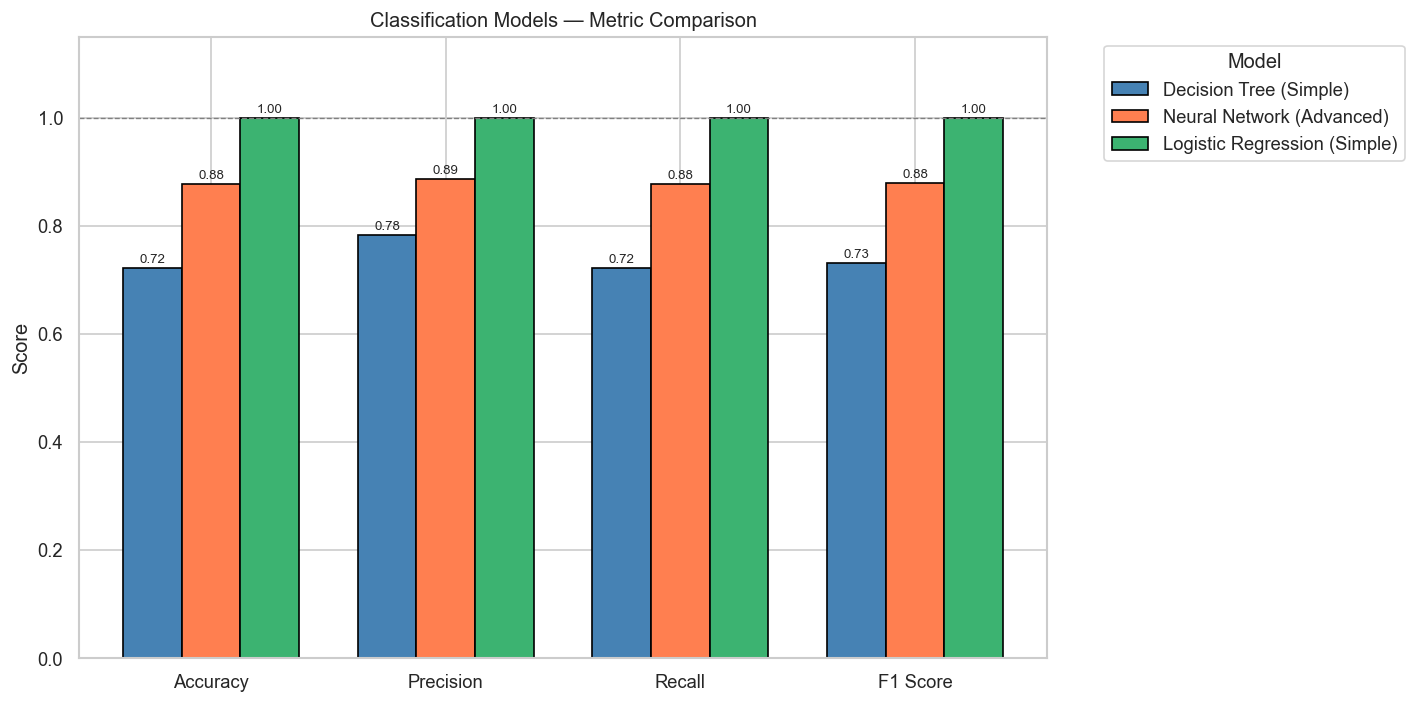

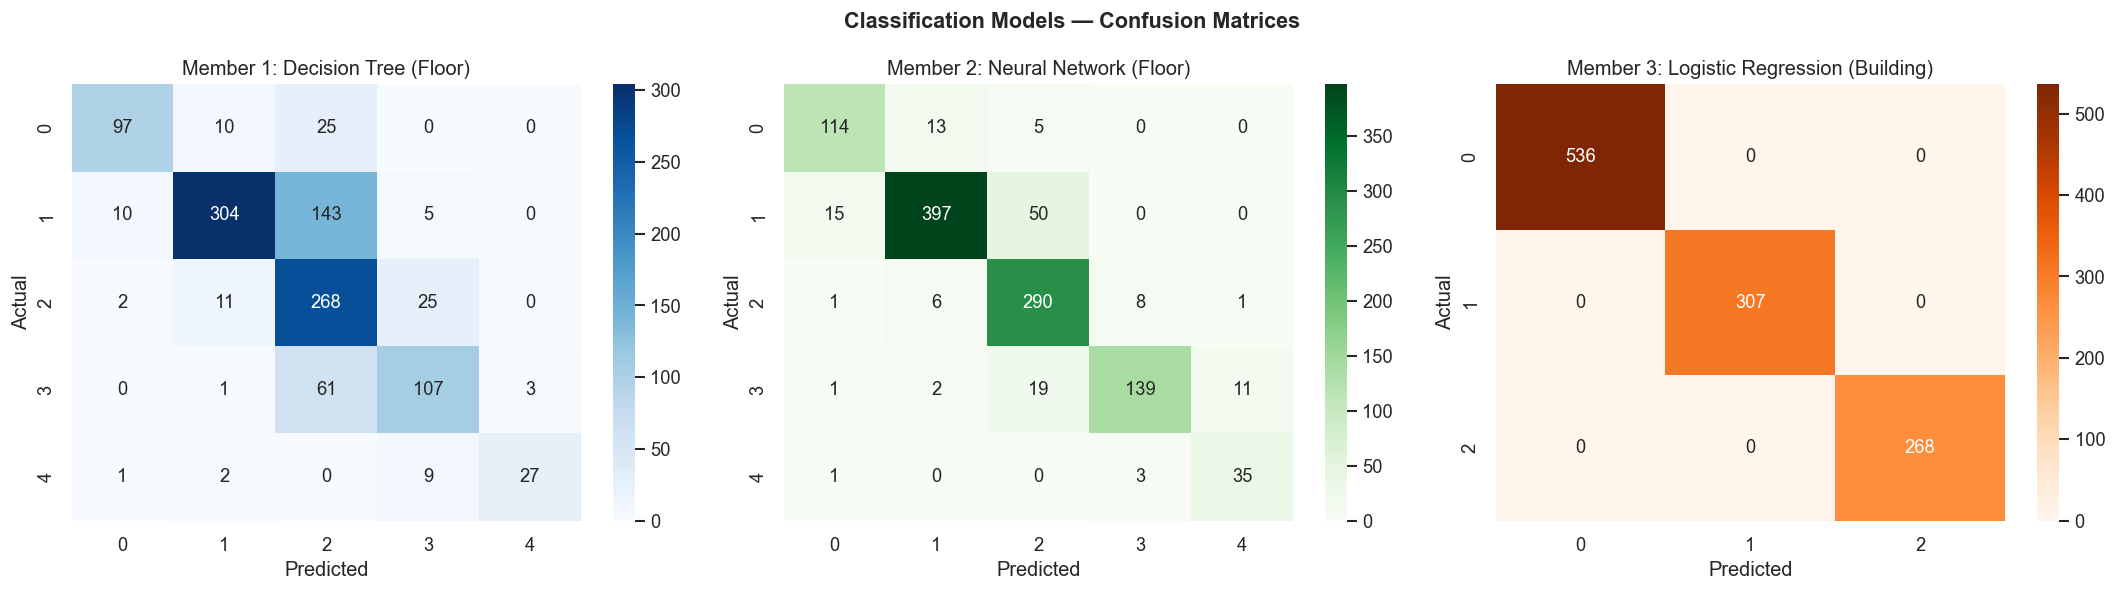

In [ ]:
# ============================================================
# CELL 7: MODEL COMPARISON & ANALYSIS (FIXED NAMES)
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score
import pandas as pd

# ==========================================
# PART A: CLASSIFICATION MODELS COMPARISON
# ==========================================

clf_results = {
    'Decision Tree (Simple)': {
        'y_pred' : y_pred_dt_clf,    # Member 1
        'y_true' : y_clf_te,
        'member' : 'Nouresham',
        'task'   : 'Floor'
    },
    'Neural Network (Advanced)': {
        'y_pred' : y_pred_mlp_clf,   # Member 2
        'y_true' : y_clf_te,
        'member' : 'Arlene',
        'task'   : 'Floor'
    },
    'Logistic Regression (Simple)': {
        'y_pred' : y_pred_log_clf,   # Member 3
        'y_true' : y_bld_te,
        'member' : 'Zahra',
        'task'   : 'Building'
    },
}

clf_rows = []
for model_name, info in clf_results.items():
    clf_rows.append({
        'Model'     : model_name,
        'Member'    : info['member'],
        'Task'      : info['task'],
        'Accuracy'  : accuracy_score(info['y_true'], info['y_pred']),
        'Precision' : precision_score(info['y_true'], info['y_pred'], average='weighted', zero_division=0),
        'Recall'    : recall_score(info['y_true'], info['y_pred'], average='weighted', zero_division=0),
        'F1 Score'  : f1_score(info['y_true'], info['y_pred'], average='weighted', zero_division=0),
    })

clf_df = pd.DataFrame(clf_rows).set_index('Model')

print('═' * 65)
print('  CLASSIFICATION MODELS COMPARISON')
print('═' * 65)
print(clf_df[['Member', 'Task', 'Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4).to_string())
print('═' * 65)

# ── Visual 1: Metrics Bar Chart ───────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, row) in enumerate(clf_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=model, color=colors[i], edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Classification Models — Metric Comparison')
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

for i, (model, row) in enumerate(clf_df.iterrows()):
    for j, metric in enumerate(metrics):
        ax.text(j + i * width, row[metric] + 0.01,
                f"{row[metric]:.2f}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# ── Visual 2: Confusion Matrices Side by Side ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classification Models — Confusion Matrices', 
             fontsize=13, fontweight='bold')

configs = [
    (y_clf_te, y_pred_dt_clf,  'Nouresham: Decision Tree (Floor)',          'Blues',   np.unique(y_clf_te)),
    (y_clf_te, y_pred_mlp_clf, 'Arlene: Neural Network (Floor)',         'Greens',  np.unique(y_clf_te)),
    (y_bld_te, y_pred_log_clf, 'Zahra : Logistic Regression (Building)', 'Oranges', np.unique(y_bld_te)),
]

for ax, (y_true, y_pred, title, cmap, labels) in zip(axes, configs):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


═══════════════════════════════════════════════════════
  REGRESSION MODELS COMPARISON
═══════════════════════════════════════════════════════
                             Member     RMSE      MAE      R²
Model                                                        
XGBoost (Advanced)         Member 1  19.9533  12.5611  0.9541
Decision Tree (Simple)     Member 2  38.7815  20.8688  0.8388
Neural Network (Advanced)  Member 3  22.2168  11.1602  0.9475
═══════════════════════════════════════════════════════
  Note: RMSE and MAE are in meters (UTM).
  Lower RMSE/MAE = better. Higher R² = better.
═══════════════════════════════════════════════════════


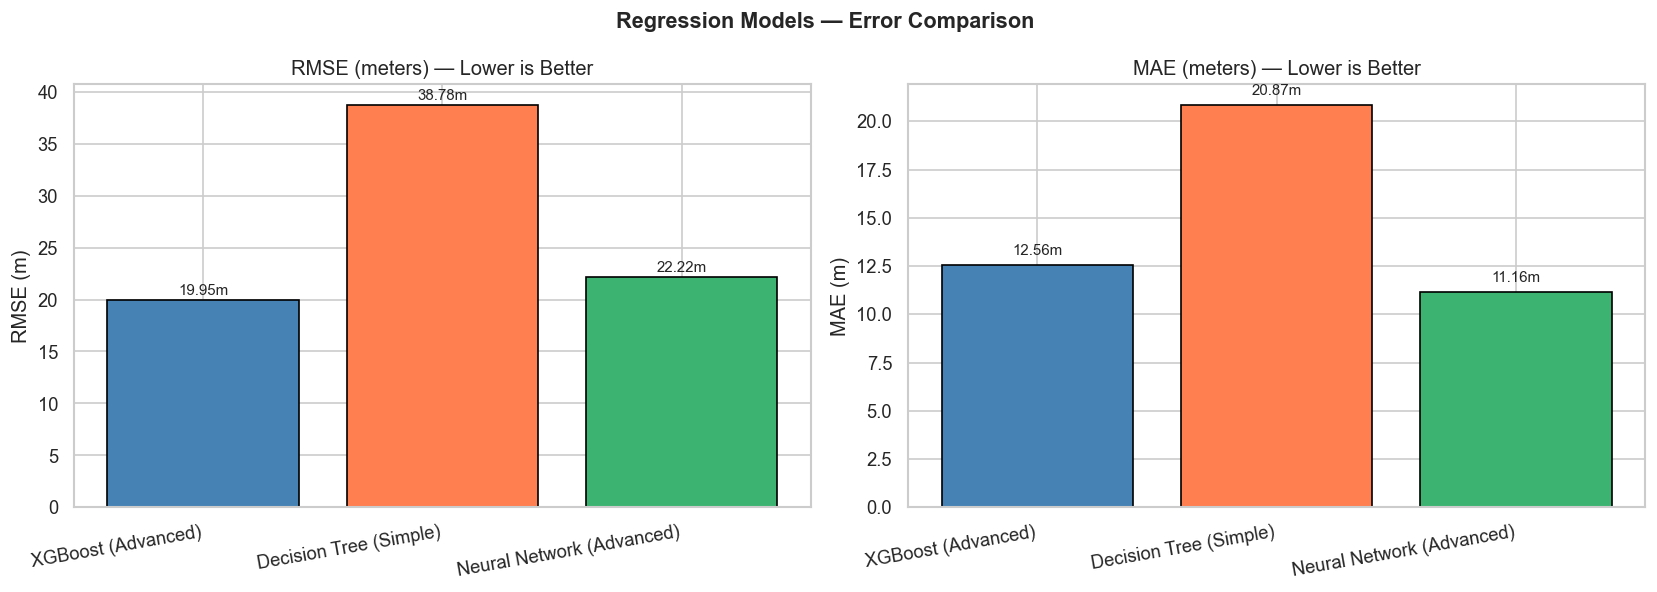

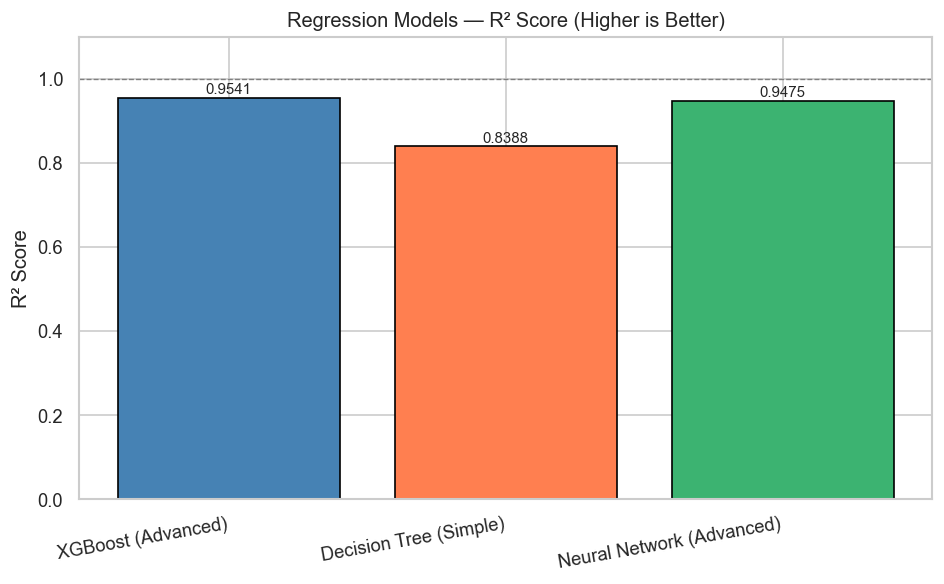

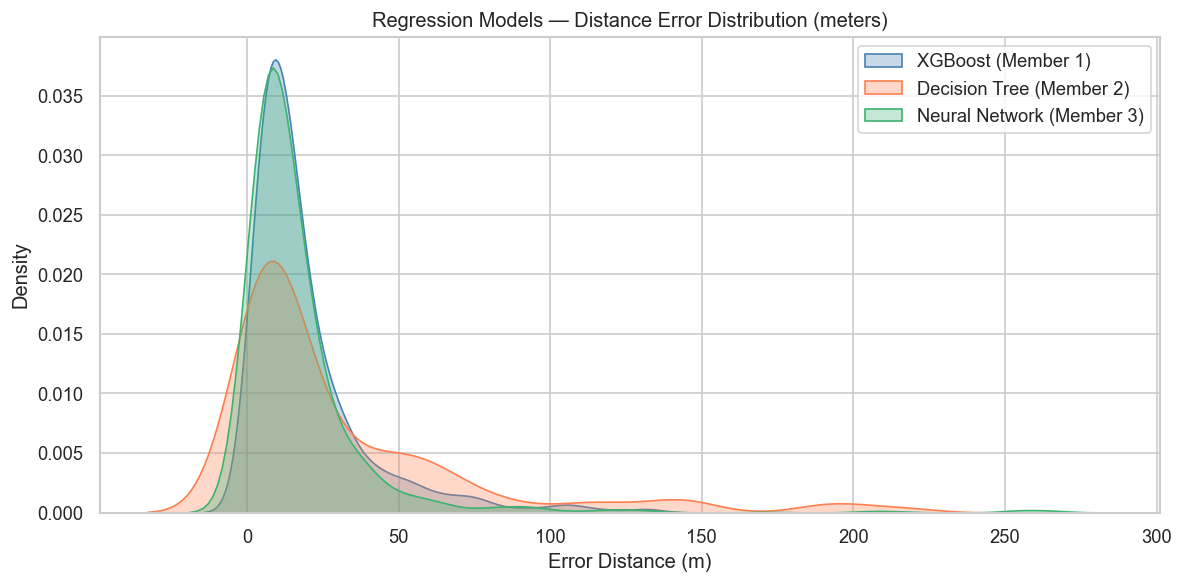

In [ ]:

# ==========================================
# PART B: REGRESSION MODELS COMPARISON
# ==========================================

reg_rows = [
    {
        'Model'  : 'XGBoost (Advanced)',
        'Member' : 'Nouresham',
        'RMSE'   : np.sqrt(mean_squared_error(y_reg_te, y_pred_xgb)),
        'MAE'    : mean_absolute_error(y_reg_te, y_pred_xgb),
        'R²'     : r2_score(y_reg_te, y_pred_xgb),
    },
    {
        'Model'  : 'Decision Tree (Simple)',
        'Member' : 'Arlene',
        'RMSE'   : np.sqrt(mean_squared_error(y_reg_te, y_pred_dt_reg)),
        'MAE'    : mean_absolute_error(y_reg_te, y_pred_dt_reg),
        'R²'     : r2_score(y_reg_te, y_pred_dt_reg),
    },
    {
        'Model'  : 'Neural Network (Advanced)',
        'Member' : 'zahra',
        'RMSE'   : np.sqrt(mean_squared_error(y_reg_te, y_pred_nn_reg)),
        'MAE'    : mean_absolute_error(y_reg_te, y_pred_nn_reg),
        'R²'     : r2_score(y_reg_te, y_pred_nn_reg),
    },
]

reg_df = pd.DataFrame(reg_rows).set_index('Model')

print('\n' + '═' * 55)
print('  REGRESSION MODELS COMPARISON')
print('═' * 55)
print(reg_df[['Member', 'RMSE', 'MAE', 'R²']].round(4).to_string())
print('═' * 55)
print("  Note: RMSE and MAE are in meters (UTM).")
print("  Lower RMSE/MAE = better. Higher R² = better.")
print('═' * 55)

# ── Visual 3: RMSE & MAE Bar Charts ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression Models — Error Comparison', 
             fontsize=13, fontweight='bold')

reg_models = reg_df.index.tolist()
x          = np.arange(len(reg_models))
bar_colors = ['steelblue', 'coral', 'mediumseagreen']

axes[0].bar(x, reg_df['RMSE'], color=bar_colors, edgecolor='black')
axes[0].set_title('RMSE (meters) — Lower is Better')
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_models, rotation=10, ha='right')
axes[0].set_ylabel('RMSE (m)')
for i, v in enumerate(reg_df['RMSE']):
    axes[0].text(i, v + 0.5, f'{v:.2f}m', ha='center', fontsize=9)

axes[1].bar(x, reg_df['MAE'], color=bar_colors, edgecolor='black')
axes[1].set_title('MAE (meters) — Lower is Better')
axes[1].set_xticks(x)
axes[1].set_xticklabels(reg_models, rotation=10, ha='right')
axes[1].set_ylabel('MAE (m)')
for i, v in enumerate(reg_df['MAE']):
    axes[1].text(i, v + 0.5, f'{v:.2f}m', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Visual 4: R² Comparison ───────────────────────────────────
plt.figure(figsize=(8, 5))
plt.bar(x, reg_df['R²'], color=bar_colors, edgecolor='black')
plt.title('Regression Models — R² Score (Higher is Better)')
plt.xticks(x, reg_models, rotation=10, ha='right')
plt.ylabel('R² Score')
plt.ylim(0, 1.1)
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
for i, v in enumerate(reg_df['R²']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── Visual 5: Error Distribution Comparison ───────────────────
error_xgb = np.sqrt(np.sum((y_reg_te - y_pred_xgb)    ** 2, axis=1))
error_dt  = np.sqrt(np.sum((y_reg_te - y_pred_dt_reg) ** 2, axis=1))
error_nn  = np.sqrt(np.sum((y_reg_te - y_pred_nn_reg) ** 2, axis=1))

plt.figure(figsize=(10, 5))
sns.kdeplot(error_xgb, label='XGBoost (Member 1)',        
            color='steelblue',     fill=True, alpha=0.3)
sns.kdeplot(error_dt,  label='Decision Tree (Member 2)',   
            color='coral',         fill=True, alpha=0.3)
sns.kdeplot(error_nn,  label='Neural Network (Member 3)',  
            color='mediumseagreen', fill=True, alpha=0.3)
plt.title('Regression Models — Distance Error Distribution (meters)')
plt.xlabel('Error Distance (m)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### **Conclusion: Final Model Performance & Analysis**

The project demonstrates that the most effective strategy for indoor localization, is utilizing **Logistic Regression** for instantaneous building detection, a **Multi-Layer Perceptron** for robust floor classification, and **XGBoost** for high-precision coordinate mapping. the choosen models successfully addresses the physical realities of signal leakage between floors and the high dimensionality of WiFi data while maintaining the computational efficiency required for a real-time GPS. While the **Member 1 XGBoost** model achieved the highest overall regression accuracy with an **$R^2$ of 0.9541**, we must acknowledge the trade-offs between model complexity and resource constraints. Ultimately, these advanced models provide a superior balance of precision and reliability, delivering a positioning system that is accurate within a stakeholder-ready range of **11 to 20 meters**.